In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

In [3]:
# Load dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names
df = pd.DataFrame(X, columns=feature_names)
df['species'] = [target_names[i] for i in y]

print(df.head())
print("\nShape:", df.shape)
print("\nClass distribution:\n", df['species'].value_counts())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

Shape: (150, 5)

Class distribution:
 species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train size: (120, 4)
Test size : (30, 4)


In [5]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)         # only transform, not fit!

In [6]:
model = LogisticRegression(
    multi_class='multinomial', 
    solver='lbfgs',              
    max_iter=200,
    random_state=42
)

model.fit(X_train, y_train)

c:\Users\vansh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=200, multi_class='multinomial', random_state=42)

In [7]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)   # probabilities for each class

print("Predictions :", y_pred)
print("Actual      :", y_test)

Predictions : [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 2 1 0 2 0]
Actual      : [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [8]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {acc * 100:.2f}%")

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))


Accuracy: 93.33%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



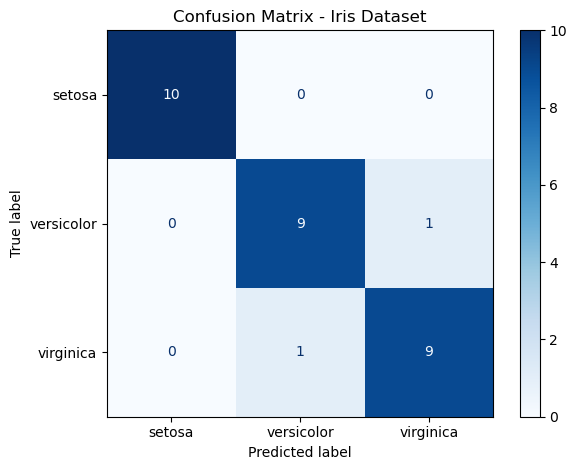

In [9]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Iris Dataset")
plt.tight_layout()
plt.show()

In [13]:
# Show predicted probabilities for first 10 test samples
prob_df = pd.DataFrame(y_prob, columns=target_names)
prob_df['Predicted'] = [target_names[i] for i in y_pred]
prob_df['Actual']    = [target_names[i] for i in y_test]

print(prob_df.head(10))
print("Accuracy Score:", acc)

     setosa  versicolor     virginica   Predicted      Actual
0  0.978818    0.021182  3.638218e-07      setosa  versicolor
1  0.003798    0.369220  6.269815e-01   virginica      setosa
2  0.148799    0.842475  8.726064e-03  versicolor   virginica
3  0.095445    0.894619  9.936370e-03  versicolor  versicolor
4  0.988493    0.011507  1.725496e-07      setosa  versicolor
5  0.018047    0.675523  3.064298e-01  versicolor      setosa
6  0.996230    0.003770  2.970222e-08      setosa  versicolor
7  0.941042    0.058957  1.299214e-06      setosa   virginica
8  0.000412    0.143891  8.556974e-01   virginica  versicolor
9  0.059959    0.737093  2.029482e-01  versicolor  versicolor
Accuracy Score: 0.9333333333333333


c:\Users\vansh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


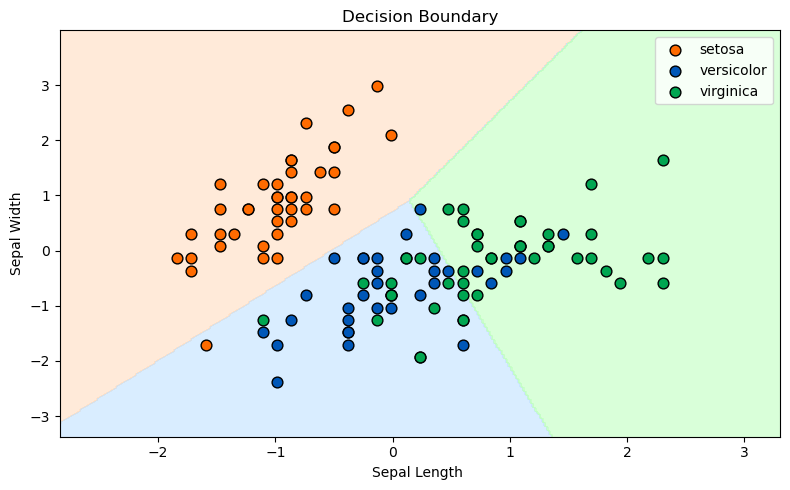

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Load data
iris = load_iris()
X, y = iris.data, iris.target
target_names = iris.target_names

# 2 features only
X_2d = X[:, :2]
X_train, X_test, y_train, y_test = train_test_split(X_2d, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200)
model.fit(X_train, y_train)

# Mesh grid
xx, yy = np.meshgrid(np.linspace(X_train[:,0].min()-1, X_train[:,0].max()+1, 300),
                     np.linspace(X_train[:,1].min()-1, X_train[:,1].max()+1, 300))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Plot
plt.figure(figsize=(8,5))
plt.contourf(xx, yy, Z, cmap=ListedColormap(['#FFDDC1','#C1E1FF','#C1FFC1']), alpha=0.6)
for i, color in zip([0,1,2], ['#FF6B00','#0057B8','#00A651']):
    plt.scatter(X_train[y_train==i,0], X_train[y_train==i,1],
                label=target_names[i], color=color, edgecolors='k', s=60)
plt.title("Decision Boundary")
plt.xlabel("Sepal Length ")
plt.ylabel("Sepal Width")
plt.legend()
plt.tight_layout()
plt.show()